# Setup and imports

In [7]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
print(f"Project root: {project_root.resolve()}")
print(f"Working dir:  {Path.cwd().resolve()}")

Project root: C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn
Working dir:  C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\notebooks


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency
from itertools import combinations
import yaml

from src.data_loader import load_data
from src.config_loader import load_config

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load data and config

In [9]:
config_path = project_root / "config" / "default.yaml"
config = load_config(str(config_path))
print(f"Experiment: {config['experiment']['name']}")
print(f"Seed: {config['experiment']['seed']}")
print()

train_path = Path(config['data']['train_path'])
test_path = Path(config['data']['test_path'])
target_col = config['data']['target_column']
id_col = config['data']['id_column']

if not train_path.is_absolute():
    train_path = project_root / train_path
if not test_path.is_absolute():
    test_path = project_root / test_path

print(f"Train path: {train_path.resolve()}")
print(f"Test path:  {test_path.resolve()}")

train_df = load_data(str(train_path))
test_df = load_data(str(test_path))

Experiment: default
Seed: 42

Train path: C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\data\processed\train.parquet
Test path:  C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\data\processed\test.parquet


In [ ]:
if target_col in train_df.columns:
    y = train_df[target_col].copy()
    X = train_df.drop(columns=[target_col])
else:
    raise ValueError(f"Target column '{target_col}' not found")

if id_col and id_col in X.columns:
    X = X.drop(columns=[id_col])
    
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

if pd.api.types.is_numeric_dtype(y):
    y_corr = y.astype(float)
    print("Target already numeric for correlation")
else:
    target_codes, target_levels = pd.factorize(y)
    y_corr = pd.Series(target_codes, index=y.index, name=f"{target_col}_encoded").astype(float)
    mapping = {str(level): int(code) for code, level in enumerate(target_levels)}
    print(f"Target encoded for correlation: {mapping}")

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Target type: {y.dtype}, unique values: {y.nunique()}")

Target encoded for correlation: {'No': 0, 'Yes': 1}
Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target type: object, unique values: 2


# Test interaction features

Top 20 Features/Interactions by Correlation:


,Feature,Type,Correlation,Abs_Correlation
1,tenure,Original,-0.418453,0.418453
11,tenure / MonthlyCharges,Divide,-0.361857,0.361857
15,MonthlyCharges / TotalCharges,Divide,0.331488,0.331488
2,MonthlyCharges,Original,0.272997,0.272997
13,tenure / TotalCharges,Divide,-0.271900,0.271900
12,tenure * TotalCharges,Multiply,-0.253927,0.253927
0,SeniorCitizen,Original,0.236362,0.236362
6,SeniorCitizen * MonthlyCharges,Multiply,0.233112,0.233112
10,tenure * MonthlyCharges,Multiply,-0.220984,0.220984
3,TotalCharges,Original,-0.218365,0.218365


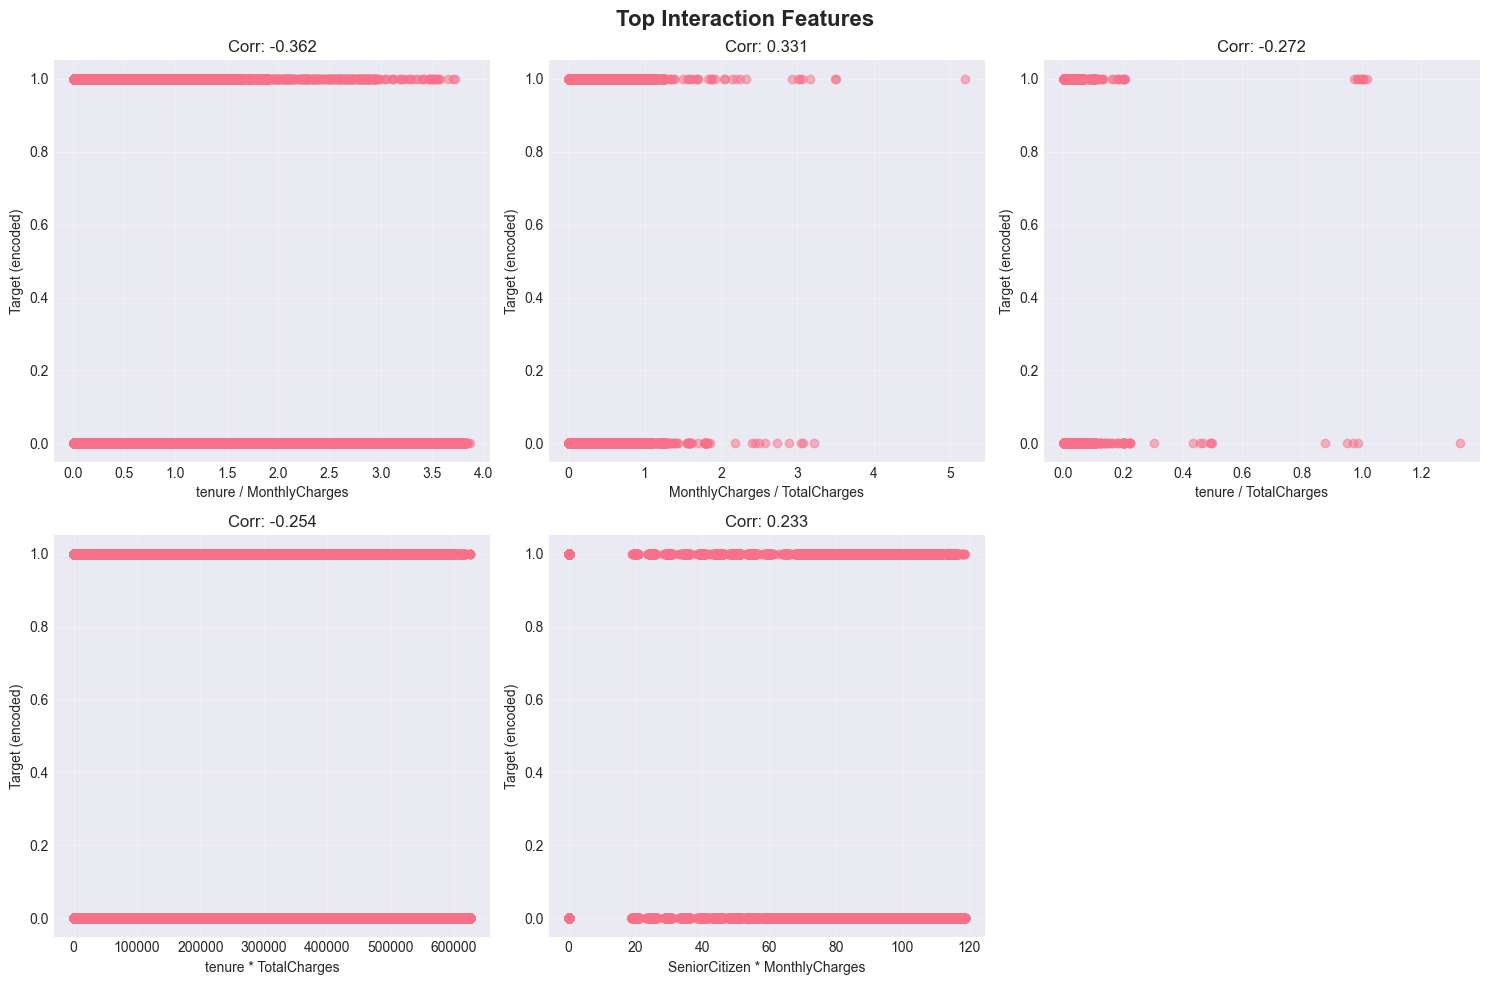

In [11]:
if len(numerical_features) >= 2:
    interaction_results = []
    
    for feat in numerical_features:
        corr = X[feat].corr(y_corr)
        interaction_results.append({
            'Feature': feat,
            'Type': 'Original',
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })
    
    for feat1, feat2 in combinations(numerical_features, 2):
        # Multiplication
        interaction = X[feat1] * X[feat2]
        corr = interaction.corr(y_corr)
        interaction_results.append({
            'Feature': f'{feat1} * {feat2}',
            'Type': 'Multiply',
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })
        
        # Division (with zero handling)
        interaction = X[feat1] / (X[feat2] + 1e-8)
        corr = interaction.corr(y_corr)
        interaction_results.append({
            'Feature': f'{feat1} / {feat2}',
            'Type': 'Divide',
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })
    
    interaction_df = pd.DataFrame(interaction_results)
    interaction_df = interaction_df.sort_values('Abs_Correlation', ascending=False)
    
    print("Top 20 Features/Interactions by Correlation:")
    display(interaction_df.head(20))
    
    top_interactions = interaction_df[interaction_df['Type'] != 'Original'].head(5)
    
    if len(top_interactions) > 0:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, row in enumerate(top_interactions.iterrows()):
            if idx >= 6:
                break
            _, data = row
            
            if ' * ' in data['Feature']:
                feat1, feat2 = data['Feature'].split(' * ')
                interaction_values = X[feat1] * X[feat2]
            elif ' / ' in data['Feature']:
                feat1, feat2 = data['Feature'].split(' / ')
                interaction_values = X[feat1] / (X[feat2] + 1e-8)
            else:
                continue
            
            axes[idx].scatter(interaction_values, y_corr, alpha=0.5)
            axes[idx].set_xlabel(data['Feature'])
            axes[idx].set_ylabel('Target (encoded)')
            axes[idx].set_title(f"Corr: {data['Correlation']:.3f}")
            axes[idx].grid(alpha=0.3)
        
        for idx in range(len(top_interactions), 6):
            axes[idx].axis('off')
        
        plt.suptitle('Top Interaction Features', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("Not enough numerical features for interaction testing")

In [15]:
if len(numerical_features) >= 2:
    original_max = interaction_df[interaction_df['Type'] == 'Original']['Abs_Correlation'].max()
    strong_interactions = interaction_df[
        (interaction_df['Type'] != 'Original') & 
        (interaction_df['Abs_Correlation'] > original_max) &
        (interaction_df['Abs_Correlation'] > 0.1)
    ]
    
    if len(strong_interactions) > 0:
        print(f"\n{len(strong_interactions)} interactions stronger than original features:\n")
        for _, row in strong_interactions.head(10).iterrows():
            print(f"  {row['Feature']}")
            print(f"    Correlation: {row['Correlation']:.4f}")
            print(f"    Type: {row['Type']}")
            print()
        
        print("Add to config/default.yaml:")
        print("feature_engineering:")
        print("  interactions:")
        for _, row in strong_interactions.head(5).iterrows():
            if ' * ' in row['Feature']:
                print(f"    - \"{row['Feature'].replace(' ', '')}\"")
    else:
        print("\nNo interactions found that outperform original features")
        print("Try domain-specific features instead")


No interactions found that outperform original features
Try domain-specific features instead


# Test binning strategies

In [16]:
if len(numerical_features) > 0:
    binning_results = []
    
    for feature in numerical_features:
        original_corr = X[feature].corr(y_corr)
        print(f"Original Pearson correlation: {original_corr:.4f}")
        
        best_chi2 = 0
        best_n_bins = 0
        best_method = None
        
        for n_bins in [3, 5, 10]:
            try:
                # Quantile binning
                quantile_bins = pd.qcut(X[feature], q=n_bins, labels=False, duplicates='drop')
                contingency = pd.crosstab(quantile_bins, y)
                chi2, p_value, _, _ = chi2_contingency(contingency)
                
                if chi2 > best_chi2:
                    best_chi2 = chi2
                    best_n_bins = n_bins
                    best_method = 'quantile'
                
                print(f"  Quantile (n={n_bins}): chi2={chi2:.2f}, p={p_value:.4f}")
                
                # Uniform binning
                uniform_bins = pd.cut(X[feature], bins=n_bins, labels=False)
                contingency = pd.crosstab(uniform_bins, y)
                chi2, p_value, _, _ = chi2_contingency(contingency)
                
                if chi2 > best_chi2:
                    best_chi2 = chi2
                    best_n_bins = n_bins
                    best_method = 'uniform'
                
                print(f"  Uniform  (n={n_bins}): chi2={chi2:.2f}, p={p_value:.4f}")
                
            except Exception as e:
                print(f"  Error with {n_bins} bins: {e}")
        
        binning_results.append({
            'Feature': feature,
            'Original_Corr': original_corr,
            'Best_Chi2': best_chi2,
            'Best_n_bins': best_n_bins,
            'Best_Method': best_method
        })
    
    binning_df = pd.DataFrame(binning_results).sort_values('Best_Chi2', ascending=False)
    display(binning_df)
else:
    print("No numerical features for binning")

Original Pearson correlation: 0.2364
  Quantile (n=3): chi2=0.00, p=1.0000
  Uniform  (n=3): chi2=33193.98, p=0.0000
  Quantile (n=5): chi2=0.00, p=1.0000
  Uniform  (n=5): chi2=33193.98, p=0.0000
  Quantile (n=10): chi2=0.00, p=1.0000
  Uniform  (n=10): chi2=33193.98, p=0.0000
Original Pearson correlation: -0.4185
  Quantile (n=3): chi2=101478.33, p=0.0000
  Uniform  (n=3): chi2=92312.41, p=0.0000
  Quantile (n=5): chi2=106623.91, p=0.0000
  Uniform  (n=5): chi2=107167.25, p=0.0000
  Quantile (n=10): chi2=113898.74, p=0.0000
  Uniform  (n=10): chi2=110836.56, p=0.0000
Original Pearson correlation: 0.2730
  Quantile (n=3): chi2=41556.23, p=0.0000
  Uniform  (n=3): chi2=41543.48, p=0.0000
  Quantile (n=5): chi2=56304.35, p=0.0000
  Uniform  (n=5): chi2=56444.16, p=0.0000
  Quantile (n=10): chi2=73794.64, p=0.0000
  Uniform  (n=10): chi2=82057.10, p=0.0000
Original Pearson correlation: -0.2184
  Quantile (n=3): chi2=31763.87, p=0.0000
  Uniform  (n=3): chi2=21034.03, p=0.0000
  Quantile 

,Feature,Original_Corr,Best_Chi2,Best_n_bins,Best_Method
1,tenure,-0.418453,113898.742929,10,quantile
2,MonthlyCharges,0.272997,82057.101029,10,uniform
3,TotalCharges,-0.218365,42507.868542,10,quantile
0,SeniorCitizen,0.236362,33193.983265,3,uniform


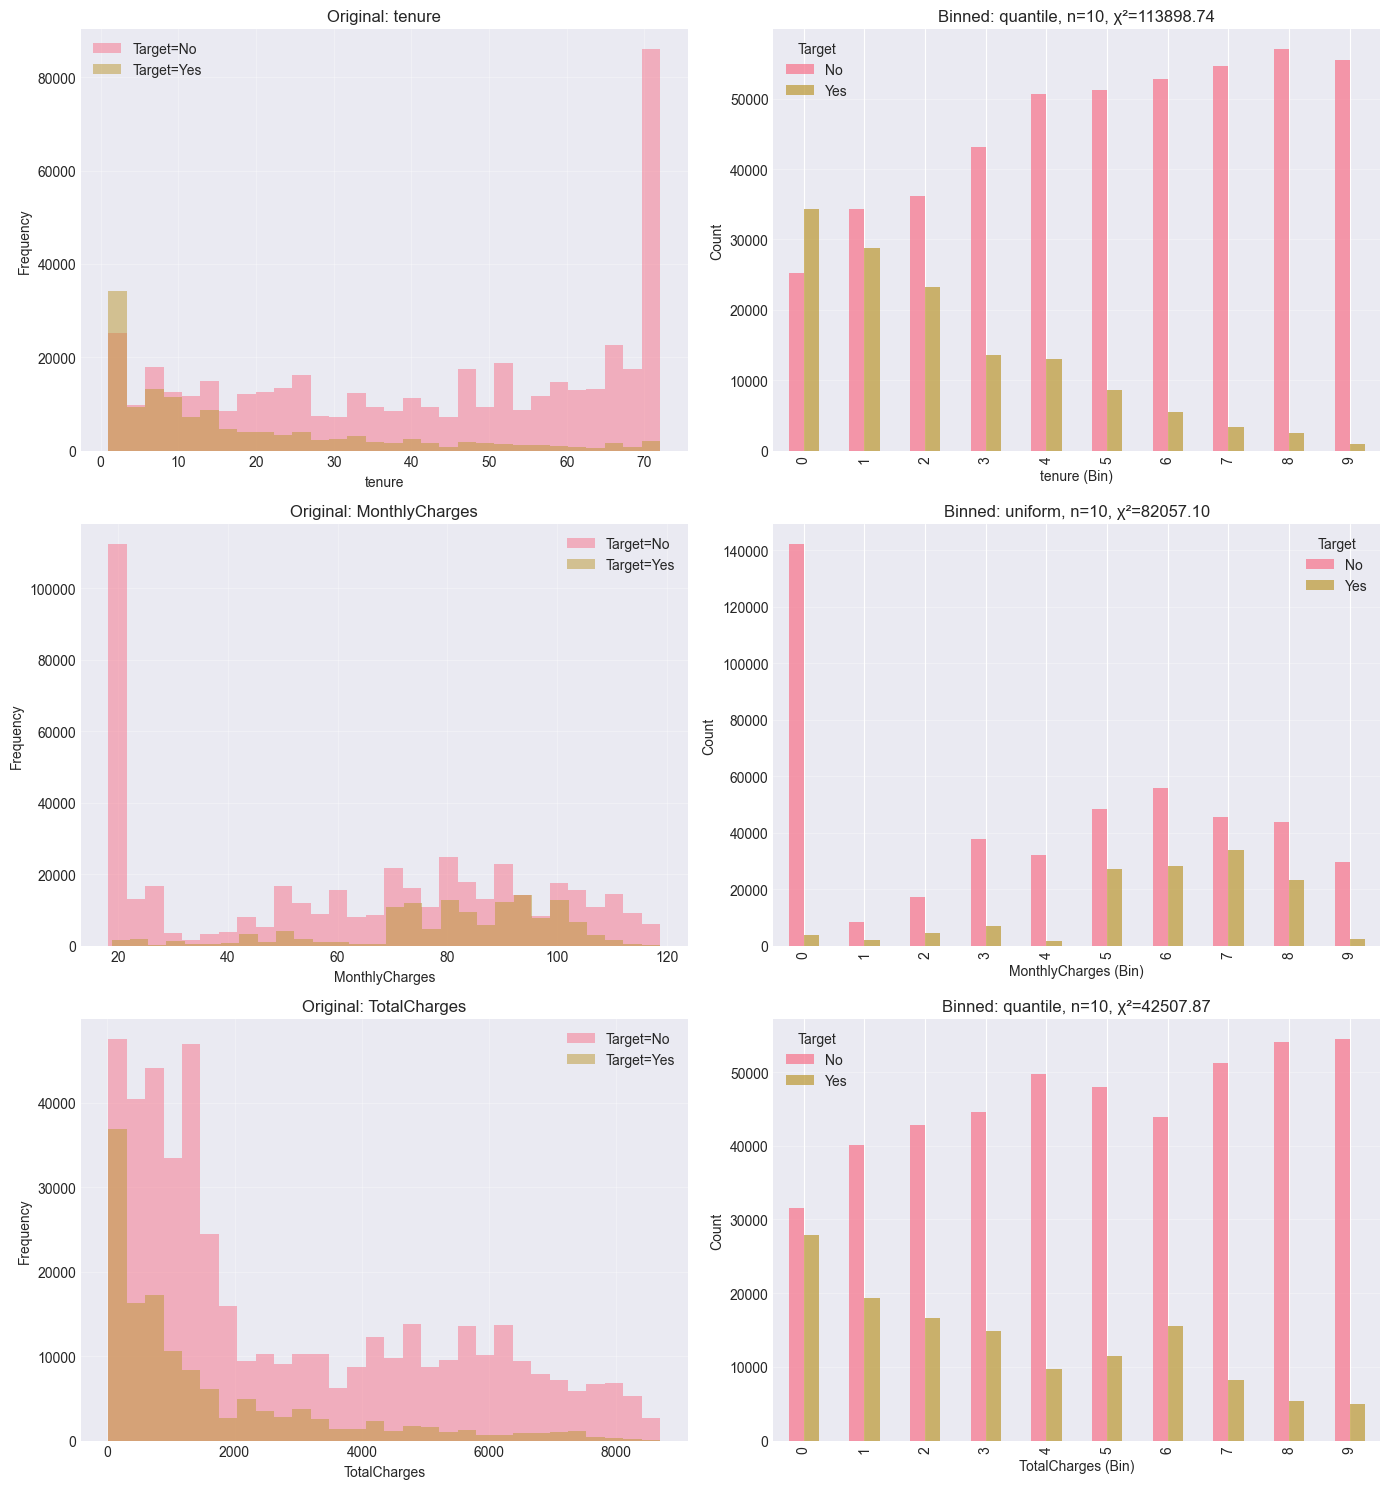

In [17]:
if len(numerical_features) > 0 and len(binning_df) > 0:
    top_features = binning_df.head(3)
    
    fig, axes = plt.subplots(len(top_features), 2, figsize=(14, 5 * len(top_features)))
    if len(top_features) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (_, row) in enumerate(top_features.iterrows()):
        feature = row['Feature']
        n_bins = int(row['Best_n_bins'])
        method = row['Best_Method']
        
        if method == 'quantile':
            binned = pd.qcut(X[feature], q=n_bins, labels=False, duplicates='drop')
        else:
            binned = pd.cut(X[feature], bins=n_bins, labels=False)
        
        # Original distribution
        for target_val in y.unique():
            mask = y == target_val
            axes[idx, 0].hist(X.loc[mask, feature], alpha=0.5, label=f'Target={target_val}', bins=30)
        axes[idx, 0].set_xlabel(feature)
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].set_title(f'Original: {feature}')
        axes[idx, 0].legend()
        axes[idx, 0].grid(alpha=0.3)
        
        # Binned distribution
        pd.crosstab(binned, y).plot(kind='bar', ax=axes[idx, 1], alpha=0.7)
        axes[idx, 1].set_xlabel(f'{feature} (Bin)')
        axes[idx, 1].set_ylabel('Count')
        axes[idx, 1].set_title(f'Binned: {method}, n={n_bins}, χ²={row["Best_Chi2"]:.2f}')
        axes[idx, 1].legend(title='Target')
        axes[idx, 1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Advanced feature engineering

In [13]:
if len(numerical_features) > 0:
    print("Testing Advanced Features:")
    print("="*60)
    
    advanced_results = []
    
    for feature in numerical_features[:3]:
        # Original
        corr = X[feature].corr(y_corr)
        advanced_results.append({
            'Feature': feature,
            'Type': 'Original',
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })
        
        # Squared
        squared = X[feature] ** 2
        corr = squared.corr(y_corr)
        advanced_results.append({
            'Feature': f'{feature}^2',
            'Type': 'Polynomial',
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })
        
        # Cubed
        cubed = X[feature] ** 3
        corr = cubed.corr(y_corr)
        advanced_results.append({
            'Feature': f'{feature}^3',
            'Type': 'Polynomial',
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })
        
        # Log (if positive values)
        if (X[feature] > 0).all():
            log_feat = np.log1p(X[feature])
            corr = log_feat.corr(y_corr)
            advanced_results.append({
                'Feature': f'log({feature})',
                'Type': 'Logarithm',
                'Correlation': corr,
                'Abs_Correlation': abs(corr)
            })
        
        # Square root
        if (X[feature] >= 0).all():
            sqrt_feat = np.sqrt(X[feature])
            corr = sqrt_feat.corr(y_corr)
            advanced_results.append({
                'Feature': f'sqrt({feature})',
                'Type': 'Root',
                'Correlation': corr,
                'Abs_Correlation': abs(corr)
            })
    
    advanced_df = pd.DataFrame(advanced_results).sort_values('Abs_Correlation', ascending=False)
    display(advanced_df)
    
    print("\nAnalysis:")
    improved = advanced_df[advanced_df['Type'] != 'Original'].head(5)
    for _, row in improved.iterrows():
        original_feat = row['Feature'].split('^2')[0].split('^3')[0].replace('log(', '').replace(')', '').replace('sqrt(', '').replace(')', '')
        if original_feat in X.columns:
            original_corr = X[original_feat].corr(y_corr)
            if abs(row['Correlation']) > abs(original_corr):
                print(f"  {row['Feature']} improved correlation!")
                print(f"  Original: {original_corr:.4f} -> New: {row['Correlation']:.4f}")

Testing Advanced Features:


,Feature,Type,Correlation,Abs_Correlation
7,log(tenure),Logarithm,-0.437900,0.437900
8,sqrt(tenure),Root,-0.436856,0.436856
4,tenure,Original,-0.418453,0.418453
5,tenure^2,Polynomial,-0.378384,0.378384
6,tenure^3,Polynomial,-0.348718,0.348718
12,log(MonthlyCharges),Logarithm,0.289381,0.289381
13,sqrt(MonthlyCharges),Root,0.283617,0.283617
9,MonthlyCharges,Original,0.272997,0.272997
10,MonthlyCharges^2,Polynomial,0.240369,0.240369
1,SeniorCitizen^2,Polynomial,0.236362,0.236362



Analysis:
  log(tenure) improved correlation!
  Original: -0.4185 -> New: -0.4379
  sqrt(tenure) improved correlation!
  Original: -0.4185 -> New: -0.4369
  log(MonthlyCharges) improved correlation!
  Original: 0.2730 -> New: 0.2894


# Feature selection analysis

Feature Importance (by correlation):


,Feature,Abs_Correlation
1,tenure,0.418453
2,MonthlyCharges,0.272997
0,SeniorCitizen,0.236362
3,TotalCharges,0.218365


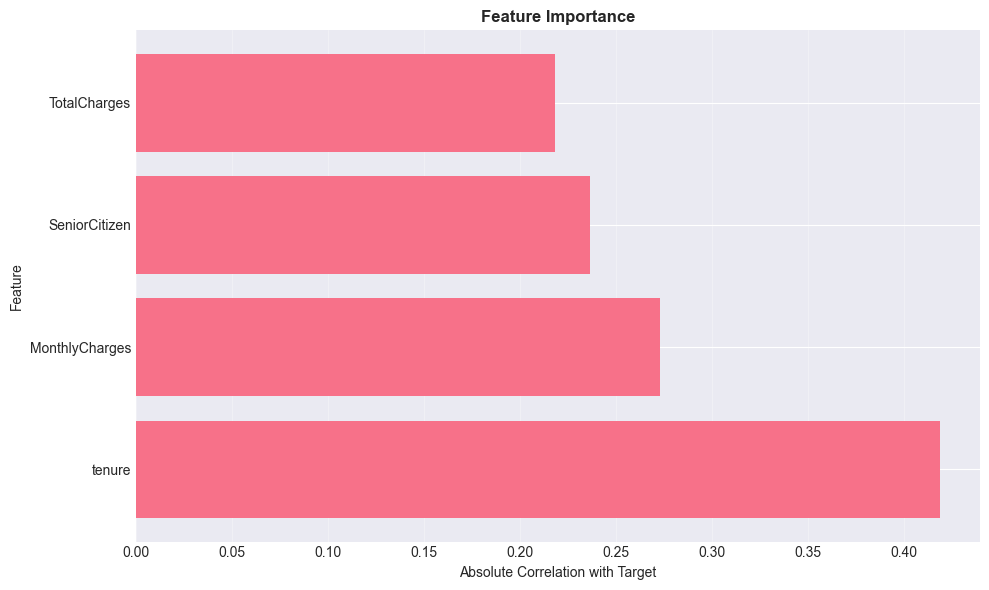


All features have |correlation| >= 0.05


In [14]:
if len(numerical_features) > 0:
    feature_importance = []
    
    for feat in numerical_features:
        corr = abs(X[feat].corr(y_corr))
        feature_importance.append({
            'Feature': feat,
            'Abs_Correlation': corr
        })
    
    importance_df = pd.DataFrame(feature_importance).sort_values('Abs_Correlation', ascending=False)
    
    print("Feature Importance (by correlation):")
    display(importance_df)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Abs_Correlation'])
    plt.xlabel('Absolute Correlation with Target')
    plt.ylabel('Feature')
    plt.title('Feature Importance', fontweight='bold')
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    threshold = 0.05
    low_value = importance_df[importance_df['Abs_Correlation'] < threshold]
    
    if len(low_value) > 0:
        print(f"\nLow-value features (|corr| < {threshold}):")
        for feat in low_value['Feature']:
            print(f"  - {feat}")
        print("\nConsider removing these from the dataset")
    else:
        print(f"\nAll features have |correlation| >= {threshold}")

# Generate config recommendations

In [18]:
recommendations = {
    'feature_engineering': {
        'enabled': True,
        'interactions': [],
        'binning': {}
    }
}

if 'interaction_df' in locals() and len(numerical_features) >= 2:
    original_max = interaction_df[interaction_df['Type'] == 'Original']['Abs_Correlation'].max()
    strong_interactions = interaction_df[
        (interaction_df['Type'] != 'Original') & 
        (interaction_df['Abs_Correlation'] > original_max) &
        (interaction_df['Abs_Correlation'] > 0.1)
    ]
    
    for _, row in strong_interactions.head(5).iterrows():
        if ' * ' in row['Feature']:
            recommendations['feature_engineering']['interactions'].append(
                row['Feature'].replace(' ', '')
            )

if 'binning_df' in locals() and len(binning_df) > 0:
    significant_binning = binning_df[binning_df['Best_Chi2'] > 10].head(3)
    
    for _, row in significant_binning.iterrows():
        feature = row['Feature']
        n_bins = int(row['Best_n_bins'])
        
        if row['Best_Method'] == 'quantile':
            bin_edges = X[feature].quantile(np.linspace(0, 1, n_bins + 1)).tolist()
        else:
            bin_edges = np.linspace(X[feature].min(), X[feature].max(), n_bins + 1).tolist()
        
        recommendations['feature_engineering']['binning'][feature] = [round(b, 2) for b in bin_edges]

output_dir = project_root / "notebooks" / "archive"
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "feature_engineering_recommendations.yaml"

with open(output_file, 'w') as f:
    yaml.dump(recommendations, f, default_flow_style=False, sort_keys=False)

print(yaml.dump(recommendations, default_flow_style=False, sort_keys=False))
print(f"\n  Saved to: {output_file}")

feature_engineering:
  enabled: true
  interactions: []
  binning:
    tenure:
    - 1.0
    - 3.0
    - 9.0
    - 16.0
    - 24.0
    - 35.0
    - 47.0
    - 57.0
    - 66.0
    - 71.0
    - 72.0
    MonthlyCharges:
    - 18.25
    - 28.3
    - 38.35
    - 48.4
    - 58.45
    - 68.5
    - 78.55
    - 88.6
    - 98.65
    - 108.7
    - 118.75
    TotalCharges:
    - 18.8
    - 176.3
    - 515.25
    - 765.35
    - 1090.95
    - 1433.65
    - 2156.25
    - 3462.1
    - 4908.25
    - 6312.9
    - 8684.8


  Saved to: c:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\notebooks\archive\feature_engineering_recommendations.yaml
